In [5]:
from MLtools import ImageData, SC_Model
from torch.utils.data import DataLoader, random_split
import torch
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from torchvision.transforms import Resize

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = torch.load("SC_model1.pth", weights_only=False).to(device)

In [3]:
name = "test.jpg"
transform = Resize((640,640))

image = imageio.imread(name)
image = image.swapaxes(0,2).swapaxes(1,2)/255.0
image = torch.from_numpy(image)
image = transform(image)
image = torch.unsqueeze(image, 0)

print(image.shape)

torch.Size([1, 3, 640, 640])


In [4]:
with torch.no_grad():
    heat_map = model(image.float().to(device)).view((640,640))

heat_map.shape

torch.Size([640, 640])

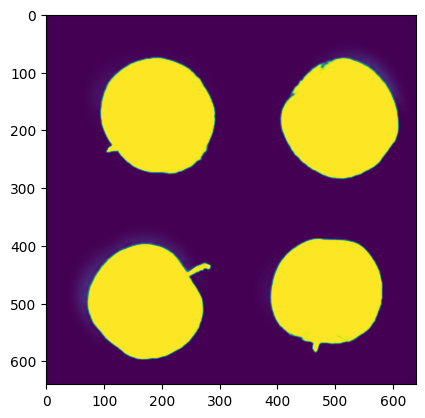

In [5]:
heat_map = heat_map.to('cpu').numpy()
plt.imshow(heat_map)

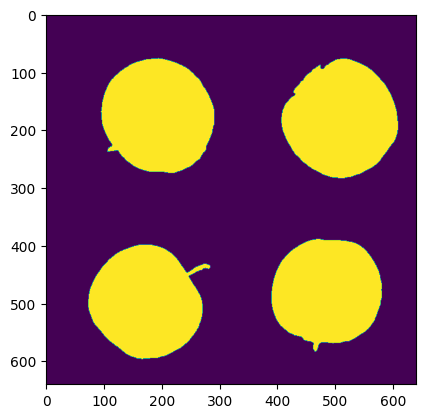

In [6]:
ind = np.where(heat_map > 0.9)
pic = np.zeros((640,640))
pic[ind] = 1
plt.imshow(pic)

In [7]:
print(f'N pixels: {len(ind[0])}')

N pixels: 118823


In [8]:
len(ind[0])/640**2

0.29009521484375

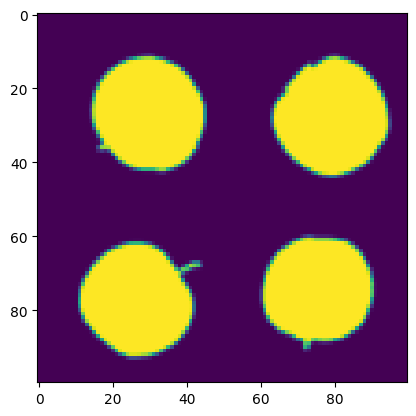

In [9]:
tr = Resize((100, 100))

pic = torch.from_numpy(pic)
pic = torch.unsqueeze(pic, 0)
pic = tr(pic).view((100,100)).numpy()

ind = np.where(pic > 0.9)

plt.imshow(pic)

In [10]:
X = []
for i in range(len(ind[0])):
    X.append([ind[0][i], ind[1][i]])

In [17]:
from sklearn.cluster import MeanShift

clustering = MeanShift(bandwidth=20).fit(X)

In [18]:
len(clustering.cluster_centers_)

4

In [19]:
clustering.cluster_centers_

array([[28.01564723, 79.15078236],
       [27.08100147, 29.81148748],
       [77.45864662, 26.39398496],
       [74.50871632, 75.42630745]])

## Full pipline prototype

In [79]:
from torchvision.io import read_image
from torchvision.transforms import Resize
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

class Reshala():
    def __init__(self, image_area):
        # тут позже будет загруженна обученная на клссификацию модель
        self.classifier = None

        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

        self.segmentator = torch.load("SC_model1.pth", weights_only=False).to(self.device)
        self.segmentator.eval()

        self.class_dict = {
            'apple': 20,
            'hurma': 20
        }
        self.image_area = image_area

    def _load_image(self, path):
        image = read_image(path)
        
        transform = Resize((640,640))
        image = transform(image/255.0)
        image = torch.unsqueeze(image, 0)

        return image.float()

    def _get_cluster_data(self, image, img_class):
        """returning list of every fruit centers and ratio of fruits area"""
        with torch.no_grad():
            class_map_orig = self.segmentator(image.to(self.device))
            
        N_pixels = len(np.where(class_map_orig.view((640,640)).to('cpu').numpy() > 0.9)[0])
        
        # на пока что переводим все тепловые карты класса к одному и тому же размеру 100 на 100
        class_map = Resize((100,100))(class_map_orig)
        class_map = class_map.to('cpu').numpy()[0,0,:,:]

        ind = np.where(class_map > 0.9)
        
        X = []
        for i in range(len(ind[0])):
            X.append([ind[0][i], ind[1][i]])

        clustering = MeanShift(bandwidth=self.class_dict[img_class]).fit(X)

        return clustering.cluster_centers_, N_pixels/640**2, class_map_orig[0,0,:,:]

    def _get_class_label(self, image):
        # Work in progres...
        return 'apple'

    
    def __call__(self, path, draw=False):
        """returs avg fruit area and fruit centers"""
        image = self._load_image(path)

        label = self._get_class_label(image)
        centers, area_ratio, class_map = self._get_cluster_data(image, label)

        if draw:
            self._draw_results(image, class_map, centers*6.4)

        return area_ratio*self.image_area/len(centers), centers*6.4

    def _draw_results(self, image, mask, centers, mask_koef=0.5):
        np_image = torch.squeeze(image, 0).to('cpu').numpy()
        np_image = np_image.swapaxes(1,2).swapaxes(0,2)

        cmap = plt.get_cmap('jet')
        rgba_img = cmap(mask.to('cpu').numpy())
        rgb_img = np.delete(rgba_img, 3, 2)

        np_image = mask_koef*rgb_img + (1.0-mask_koef)*np_image

        plt.imshow(np_image)
        plt.scatter(centers[:,0], centers[:,1], c='blue', s=100)

        plt.show()


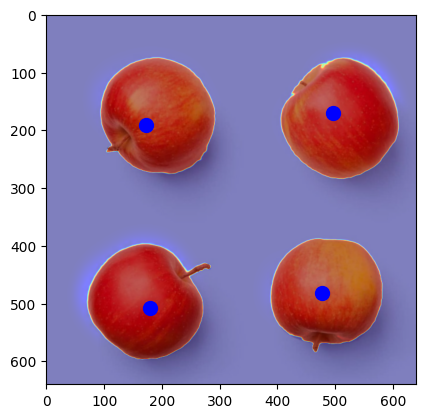

(7.25238037109375,
 array([[179.16424581, 506.74413408],
        [172.50701001, 190.27868383],
        [495.91504425, 169.04306785],
        [476.6755832 , 482.07029549]]))

In [80]:
a = Reshala(100)

a("test.jpg", True)